In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
from evalviz.config import load_runs_from_files, load_methods, load_benchmarks
from evalviz.io import load_results_from_runs
from evalviz.preprocess import apply_mappings, add_dataset_type_columns, apply_dataset_merge_rules
from evalviz.enrich import attach_method_metadata, attach_benchmark_metadata
from evalviz.capabilities import (
    annotate_capabilities_hierarchical,
    get_capability_ordering,
)
from evalviz.benchmarks import build_subset_capability_lookup
import tueplots
from tueplots import figsizes
import re

ours = "configs/runs_ours_final.json"
# ours = "configs/runs_openclip.json"

runs = load_runs_from_files(
    "configs/runs_baselines.json",
    "configs/runs_external.json",
    ours
)

methods = load_methods("configs/methods.json")
bench_cfg = load_benchmarks("configs/benchmarks.json")

df = load_results_from_runs(runs)
df = apply_dataset_merge_rules(df, bench_cfg)
df = apply_mappings(df, bench_cfg)
df = add_dataset_type_columns(df)
df = attach_method_metadata(df, methods)
df = attach_benchmark_metadata(df, bench_cfg)

# Build capability lookup and annotate with hierarchical capabilities
subset_cap_lookup = build_subset_capability_lookup(bench_cfg)
df = annotate_capabilities_hierarchical(df, subset_cap_lookup, bench_cfg)

# Get canonical ordering for tables/plots
TOP_CAPS, SUB_CAPS = get_capability_ordering(bench_cfg)
print(f"Top-level capabilities: {TOP_CAPS}")
print(f"Sub-level capabilities: {SUB_CAPS}")

# Show sample of capability columns
df[["run_label", "dataset", "subset", "capability_top", "capability_sub"]].drop_duplicates().head(10)

Top-level capabilities: ['EntityContent', 'RelationalStructure', 'Binding', 'Linguistic']
Sub-level capabilities: ['ObjectRecognition', 'AttributeRecognition', 'CountingQuantity', 'ExistencePresence', 'PredicateSensitivity', 'RoleSensitivity', 'AttributeBinding', 'WordOrderSyntax', 'Coreference', 'Negation']


,run_label,dataset,subset,capability_top,capability_sub
692,NegCLIP (COCO),ARO,VG_Relation,RelationalStructure,PredicateSensitivity
3126,FSC CLIP (LAION+COCO),VL_CheckList,obj_location,EntityContent,ObjectRecognition
4575,READCLIP,ARO,VG_Attribution,Binding,AttributeBinding
6456,DAC (SAM),ColorFoil,all,EntityContent,AttributeRecognition
5988,DAC (LLM),ColorFoil,all,EntityContent,AttributeRecognition
1190,CE CLIP,ColorFoil,all,EntityContent,AttributeRecognition
3208,FSC CLIP (LAION+COCO),ARO,VG_Relation,RelationalStructure,PredicateSensitivity
6972,LaCLIP (CC12M),ARO,VG_Relation,RelationalStructure,PredicateSensitivity
8265,CS-CLIP,VL_CheckList,obj_location,EntityContent,ObjectRecognition
2224,FSC CLIP (CC3M),ColorFoil,all,EntityContent,AttributeRecognition


In [5]:
import matplotlib.pyplot as plt
plt.rcParams.update(
    figsizes.icml2024_full()
)

In [6]:
import numpy as np
from evalviz.tables import build_capability_table

# Get capability tables for plotting
cap_table_top, _ = build_capability_table(df, level="top")
cap_table_sub, _ = build_capability_table(df, level="sub")

# Transpose to get models as rows
cap_table_top = cap_table_top.T  # rows=models, cols=capabilities
cap_table_sub = cap_table_sub.T

# Models to show in radar plot
show_models = ["CLIP", "NegCLIP", "CS-CLIP"]

# Add top 3 other performers (by mean across capabilities)
mean_scores = cap_table_top.mean(axis=1)
mean_scores = mean_scores.drop(labels=[m for m in show_models if m in mean_scores.index], errors='ignore')
top_others = mean_scores.nlargest(5).index.tolist()
show_models = show_models + top_others

print(f"Models for radar plot: {show_models}")
print(f"Top-level capabilities: {list(cap_table_top.columns)}")
print(f"Sub-level capabilities: {list(cap_table_sub.columns)}")

Models for radar plot: ['CLIP', 'NegCLIP', 'CS-CLIP', 'READCLIP', 'FSC CLIP (COCO)', 'NegCLIP (COCO)', 'DeGLA', 'CLIC CogVLM (PixPR RedCaps)']
Top-level capabilities: ['Binding', 'EntityContent', 'Linguistic', 'RelationalStructure']
Sub-level capabilities: ['AttributeBinding', 'AttributeRecognition', 'Coreference', 'CountingQuantity', 'ExistencePresence', 'Negation', 'ObjectRecognition', 'PredicateSensitivity', 'RoleSensitivity', 'WordOrderSyntax']


# Figures

Available models: ['CE CLIP', 'CLIC CogVLM (LAION)', 'CLIC CogVLM (PixPR RedCaps)', 'CLIP', 'CLoVe', 'CON CLIP', 'CS-CLIP', 'DAC (LLM)', 'DAC (SAM)', 'DeGLA', 'FSC CLIP (CC3M)', 'FSC CLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'LaCLIP (CC12M)', 'LabCLIP', 'NegCLIP (COCO)', 'READCLIP', 'TSVLC', 'TripletCLIP (CC12M)']
Available datasets: ['ARO', 'BLA', 'COCO-CF', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']
✓ NegCLIP (COCO)
✓ CS-CLIP
✓ FSC CLIP (COCO)
✓ READCLIP
✓ DeGLA


/tmp/ipykernel_3720263/290359618.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3720263/290359618.py:205: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


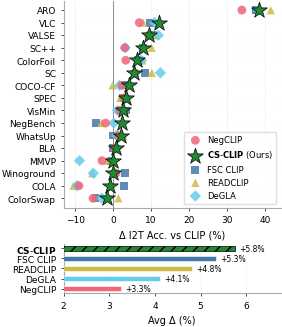


Figure saved to figures/delta_vs_clip_dataset_dotplot.pdf


In [7]:
# =============================================================================
# HORIZONTAL DOT PLOT: Delta Accuracy vs CLIP per Dataset (+ Average Summary)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from pathlib import Path
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes
from evalviz.tables import build_summary_table

# Output directory
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Update plot style
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Colorblind-friendly palette (Paul Tol's bright)
COLORBLIND_PALETTE = [f"#{c}" if not str(c).startswith("#") else str(c) for c in palettes.paultol_bright]

# =============================================================================
# BUILD DATASET-LEVEL TABLE
# =============================================================================
dataset_table, run_info = build_summary_table(df, metric="text_contrastive_accuracy", benchmark_type="compositional")

print("Available models:", list(dataset_table.index))
print("Available datasets:", list(dataset_table.columns))

# =============================================================================
# DATASET DISPLAY NAME MAPPING
# =============================================================================
DATASET_DISPLAY_NAMES = {
    "VL_CheckList": "VLC",
    "SugarCrepe++": "SC++",
    "SugarCrepe": "SC",
    "ControlledImages": "WhatsUp",
}

def get_display_name(dataset):
    """Get display name for a dataset."""
    return DATASET_DISPLAY_NAMES.get(dataset, dataset)

# =============================================================================
# MODEL STYLING
# =============================================================================
MODEL_STYLES = {
    "NegCLIP (COCO)": {"color": COLORBLIND_PALETTE[1], "marker": "o", "size": 50, "zorder": 5},
    "CS-CLIP": {"color": COLORBLIND_PALETTE[2], "marker": "*", "size": 160, "zorder": 10, "edgecolor": "white", "linewidth": 0.8},
    "FSC CLIP (COCO)": {"color": COLORBLIND_PALETTE[0], "marker": "s", "size": 40, "zorder": 4},
    "READCLIP": {"color": COLORBLIND_PALETTE[3], "marker": "^", "size": 45, "zorder": 4},
    "DeGLA": {"color": COLORBLIND_PALETTE[4], "marker": "D", "size": 42, "zorder": 4},
}

SHOW_MODELS = ["NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]

# Get CLIP baseline
baseline_label = "CLIP"
if baseline_label not in dataset_table.index:
    raise ValueError(f"Baseline '{baseline_label}' not found")
clip_data = dataset_table.loc[baseline_label]

# =============================================================================
# CALCULATE DELTAS
# =============================================================================
delta_data = {}
for model in SHOW_MODELS:
    if model in dataset_table.index:
        delta_data[model] = (dataset_table.loc[model] - clip_data) * 100
        print(f"✓ {model}")
    else:
        print(f"✗ {model} not found")

# Sort datasets by CS-CLIP delta
datasets = list(dataset_table.columns)
if "CS-CLIP" in delta_data:
    datasets = sorted(datasets, key=lambda d: delta_data["CS-CLIP"].get(d, 0), reverse=True)

# =============================================================================
# CREATE COMPACT FIGURE (smaller, tighter layout)
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(2.8, 3.8), 
                          gridspec_kw={'height_ratios': [5, 1.2], 'hspace': 0.28})

ax_dots = axes[0]
ax_bars = axes[1]

# --- DOT PLOT (Top) ---
y_positions = np.arange(len(datasets))

# Vertical line at x=0
ax_dots.axvline(x=0, color='#666666', linestyle='-', linewidth=0.6, zorder=1)

# Plot each model
for model in SHOW_MODELS:
    if model not in delta_data:
        continue
    
    style = MODEL_STYLES.get(model, {"color": "#888888", "marker": "o", "size": 40, "zorder": 3})
    deltas = [delta_data[model].get(d, np.nan) for d in datasets]
    
    # Display name - BOLD for CS-CLIP
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    # Highlight CS-CLIP markers with subtle edge
    if model == "CS-CLIP":
        ax_dots.scatter(
            deltas, y_positions,
            s=style.get("size", 40) * 0.9,
            c=style.get("color"),
            marker=style.get("marker", "o"),
            edgecolor="black",
            linewidth=0.5,
            alpha=1.0,
            zorder=style.get("zorder", 3),
            label=label
        )
    else:
        ax_dots.scatter(
            deltas, y_positions,
            s=style.get("size", 40) * 0.8,
            c=style.get("color"),
            marker=style.get("marker", "o"),
            edgecolor=style.get("edgecolor", "none"),
            linewidth=style.get("linewidth", 0),
            alpha=0.85,
            zorder=style.get("zorder", 3),
            label=label
        )

# Y-axis labels (with display names)
ax_dots.set_yticks(y_positions)
ax_dots.set_yticklabels([get_display_name(d) for d in datasets], fontsize=6.5)
ax_dots.set_xlabel("Δ I2T Acc. vs CLIP (%)", fontsize=7)

# Legend - bottom right, more compact
ax_dots.legend(
    loc='lower right',
    fontsize=6,
    framealpha=0.92,
    edgecolor='#dddddd',
    fancybox=False,
    handletextpad=0.4,
    borderpad=0.4,
)

# Style - better grid
ax_dots.set_facecolor("white")
ax_dots.grid(True, axis='x', alpha=0.4, linestyle='-', linewidth=0.4, color='#cccccc', zorder=0)
ax_dots.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.3, color='#dddddd', zorder=0)
ax_dots.spines["top"].set_visible(False)
ax_dots.spines["right"].set_visible(False)
ax_dots.spines["left"].set_color("#aaaaaa")
ax_dots.spines["bottom"].set_color("#aaaaaa")
ax_dots.tick_params(axis='both', length=2, width=0.5, labelsize=6.5)
ax_dots.invert_yaxis()

# --- AVERAGE BAR CHART (Bottom) ---
avg_deltas = {m: delta_data[m].mean() for m in SHOW_MODELS if m in delta_data}
sorted_models = sorted(avg_deltas.keys(), key=lambda m: avg_deltas[m], reverse=True)

y_bar = np.arange(len(sorted_models))
bar_colors = [MODEL_STYLES.get(m, {}).get("color", "#888888") for m in sorted_models]
bar_values = [avg_deltas[m] for m in sorted_models]

# Plot bars with hatching for CS-CLIP (like combined figure)
for i, (m, val, color) in enumerate(zip(sorted_models, bar_values, bar_colors)):
    hatch = '///' if m == "CS-CLIP" else None
    edgecolor = 'black' if m == "CS-CLIP" else 'white'
    lw = 0.5 if m == "CS-CLIP" else 0.4
    ax_bars.barh(i, val, color=color, edgecolor=edgecolor, linewidth=lw, height=0.5, hatch=hatch, zorder=3)
    ax_bars.text(val + 0.1, i, f'+{val:.1f}%', va='center', ha='left', fontsize=5.5)

# Model labels
bar_labels = []
for m in sorted_models:
    display_name = m.replace(" (COCO)", "").replace(" (CC3M)", "")
    if m == "CS-CLIP":
        bar_labels.append(r"$\mathbf{CS\text{-}CLIP}$")
    else:
        bar_labels.append(display_name)

ax_bars.set_yticks(y_bar)
ax_bars.set_yticklabels(bar_labels, fontsize=6.5)
ax_bars.set_xlabel("Avg Δ (%)", fontsize=7)

# Style
ax_bars.set_facecolor("white")
ax_bars.grid(True, axis='x', alpha=0.3, linestyle='-', linewidth=0.3, color='#cccccc', zorder=0)
ax_bars.spines["top"].set_visible(False)
ax_bars.spines["right"].set_visible(False)
ax_bars.spines["left"].set_color("#aaaaaa")
ax_bars.spines["bottom"].set_color("#aaaaaa")
ax_bars.tick_params(axis='both', length=2, width=0.5, labelsize=6.5)
ax_bars.invert_yaxis()

# X-axis limits - START FROM 2 (like combined figure)
ax_bars.set_xlim(2, max(bar_values) + 1.0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "delta_vs_clip_dataset_dotplot.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "delta_vs_clip_dataset_dotplot.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'delta_vs_clip_dataset_dotplot.pdf'}")

ZS datasets: ['wds_imagenet-o', 'wds_imagenet1k', 'wds_imagenet_sketch', 'wds_imagenetv2', 'wds_sun397', 'wds_vtab-caltech101', 'wds_vtab-cifar10']
Retrieval T2I datasets: ['wds_flickr8k', 'wds_mscoco_captions']
Retrieval I2T datasets: ['wds_flickr8k', 'wds_mscoco_captions']

=== Delta vs CLIP (%) ===
Comp I2T: {'NegCLIP (COCO)': np.float64(3.2543761130198523), 'CS-CLIP': np.float64(5.754863075303051), 'FSC CLIP (COCO)': np.float64(5.333836969535499), 'READCLIP': np.float64(4.8074012419051515), 'DeGLA': np.float64(4.112903771993592)}
Comp T2I: {'NegCLIP (COCO)': np.float64(-0.18097166509472018), 'CS-CLIP': np.float64(1.1522183285325283), 'FSC CLIP (COCO)': np.float64(1.3553227582083383), 'READCLIP': np.float64(0.051465030128206024), 'DeGLA': np.float64(-0.2768192266315084)}
Comp Group: {'NegCLIP (COCO)': np.float64(-0.8128995225635094), 'CS-CLIP': np.float64(1.3326509664431274), 'FSC CLIP (COCO)': np.float64(1.2552717398146895), 'READCLIP': np.float64(0.2298661771173438), 'DeGLA': np.f

/tmp/ipykernel_3720263/1409448703.py:143: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


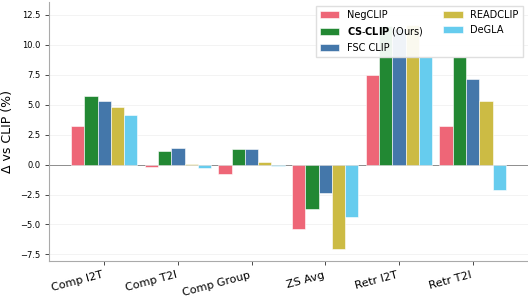


Figure saved to figures/downstream_compositional_comparison.pdf


In [8]:
# =============================================================================
# SECONDARY PLOT: Downstream + Compositional Summary (Bar Chart)
# =============================================================================
# Shows: Retrieval (I2T, T2I), Zero-Shot Accuracy, Compositional (T2I, Group Avg)

import matplotlib.pyplot as plt
import numpy as np
from evalviz.tables import build_summary_table
from evalviz.downstream import build_downstream_table

# =============================================================================
# GATHER METRICS
# =============================================================================

# Models to show (same as dot plot)
SHOW_MODELS = ["NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
baseline_label = "CLIP"

# --- Compositional metrics ---
# T2I compositional (text_contrastive_accuracy already loaded in dataset_table)
comp_t2i_table, _ = build_summary_table(df, metric="image_contrastive_accuracy", benchmark_type="compositional")
comp_group_table, _ = build_summary_table(df, metric="group_contrastive_accuracy", benchmark_type="compositional")

# --- Downstream metrics ---
# Zero-shot classification
zs_table, _ = build_downstream_table(df, task="zero_shot_classification", metric="acc1")

# Retrieval
retr_t2i_table, _ = build_downstream_table(df, task="retrieval_t2i")  # text_retrieval_recall@1
retr_i2t_table, _ = build_downstream_table(df, task="retrieval_i2t")  # image_retrieval_recall@1

print("ZS datasets:", list(zs_table.columns) if not zs_table.empty else "N/A")
print("Retrieval T2I datasets:", list(retr_t2i_table.columns) if not retr_t2i_table.empty else "N/A")
print("Retrieval I2T datasets:", list(retr_i2t_table.columns) if not retr_i2t_table.empty else "N/A")

# =============================================================================
# COMPUTE AVERAGES FOR EACH METRIC CATEGORY
# =============================================================================

def get_avg(table, models, baseline):
    """Get average across all columns for given models, relative to baseline."""
    if table.empty:
        return {}
    results = {}
    if baseline in table.index:
        baseline_avg = table.loc[baseline].mean()
    else:
        baseline_avg = 0
    
    for model in models:
        if model in table.index:
            model_avg = table.loc[model].mean()
            results[model] = (model_avg - baseline_avg) * 100  # Delta in pp
    return results

def get_abs_avg(table, models):
    """Get absolute average across all columns for given models."""
    if table.empty:
        return {}
    results = {}
    for model in models:
        if model in table.index:
            results[model] = table.loc[model].mean() * 100  # Percentage
    return results

# Calculate deltas for each metric category
metrics_delta = {
    "Comp I2T": get_avg(dataset_table, SHOW_MODELS, baseline_label),  # Already have this from main plot
    "Comp T2I": get_avg(comp_t2i_table, SHOW_MODELS, baseline_label),
    "Comp Group": get_avg(comp_group_table, SHOW_MODELS, baseline_label),
    "ZS Avg": get_avg(zs_table, SHOW_MODELS, baseline_label),
    "Retr T2I": get_avg(retr_t2i_table, SHOW_MODELS, baseline_label),
    "Retr I2T": get_avg(retr_i2t_table, SHOW_MODELS, baseline_label),
}

# Print summary
print("\n=== Delta vs CLIP (%) ===")
for metric_name, deltas in metrics_delta.items():
    print(f"{metric_name}: {deltas}")

# =============================================================================
# CREATE GROUPED BAR CHART
# =============================================================================
fig, ax = plt.subplots(figsize=(5.5, 3.2))

# Metric categories to show
metric_names = ["Comp I2T", "Comp T2I", "Comp Group", "ZS Avg", "Retr I2T", "Retr T2I"]
n_metrics = len(metric_names)
n_models = len(SHOW_MODELS)

# X positions
x = np.arange(n_metrics)
bar_width = 0.18
offsets = np.linspace(-(n_models-1)/2 * bar_width, (n_models-1)/2 * bar_width, n_models)

# Plot bars for each model
for i, model in enumerate(SHOW_MODELS):
    values = [metrics_delta[m].get(model, 0) for m in metric_names]
    color = MODEL_STYLES.get(model, {}).get("color", "#888888")
    
    # Display name
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    bars = ax.bar(x + offsets[i], values, bar_width, label=label, color=color, 
                  edgecolor='white', linewidth=0.4, zorder=3)

# Horizontal line at y=0
ax.axhline(y=0, color='#666666', linestyle='-', linewidth=0.6, zorder=1)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=8, rotation=15, ha='right')
ax.set_ylabel("Δ vs CLIP (%)", fontsize=9)

# Legend
ax.legend(
    loc='upper right',
    fontsize=7,
    framealpha=0.92,
    edgecolor='#dddddd',
    fancybox=False,
    ncol=2
)

# Style
ax.set_facecolor("white")
ax.grid(True, axis='y', alpha=0.4, linestyle='-', linewidth=0.4, color='#cccccc', zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#aaaaaa")
ax.spines["bottom"].set_color("#aaaaaa")
ax.tick_params(axis='both', which='both', length=3, width=0.5)

# Adjust y-axis to show all values
y_min = min(0, min([min(metrics_delta[m].values()) for m in metric_names if metrics_delta[m]])) - 1
y_max = max([max(metrics_delta[m].values()) for m in metric_names if metrics_delta[m]]) + 2
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "downstream_compositional_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "downstream_compositional_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'downstream_compositional_comparison.pdf'}")

/tmp/ipykernel_3720263/2908214914.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3720263/2908214914.py:410: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


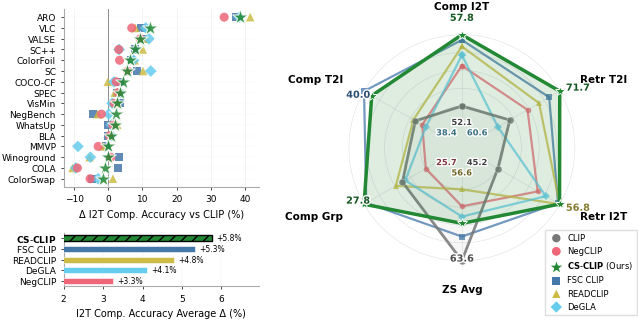


Figure saved to figures/combined_comp_downstream_figure.pdf


In [9]:
# =============================================================================
# COMBINED FIGURE: Dot Plot (Left) + Radar Plot (Right)
# =============================================================================
# Two-column ICML full-width figure with unified legend at top

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes
from evalviz.tables import build_summary_table
from evalviz.downstream import build_downstream_table

# Update plot style for ICML full width
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# =============================================================================
# DATA PREPARATION
# =============================================================================

# Include CLIP for radar plot (absolute values)
RADAR_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
SHOW_MODELS = ["NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]  # For dot plot (delta)
baseline_label = "CLIP"

# Dataset display name mapping
DATASET_DISPLAY_NAMES = {
    "VL_CheckList": "VLC",
    "SugarCrepe++": "SC++",
    "SugarCrepe": "SC",
    "ControlledImages": "WhatsUp",
}

def get_display_name(dataset):
    """Get display name for a dataset."""
    return DATASET_DISPLAY_NAMES.get(dataset, dataset)

# Add CLIP to model styles
MODEL_STYLES_FULL = MODEL_STYLES.copy()
MODEL_STYLES_FULL["CLIP"] = {"color": "#777777", "marker": "o", "size": 45, "zorder": 2}

# Compositional I2T
clip_data = dataset_table.loc[baseline_label]

# Calculate deltas for dot plot
delta_data = {}
for model in SHOW_MODELS:
    if model in dataset_table.index:
        delta_data[model] = (dataset_table.loc[model] - clip_data) * 100

# Sort datasets by CS-CLIP delta
datasets = sorted(dataset_table.columns, key=lambda d: delta_data["CS-CLIP"].get(d, 0), reverse=True)

# Compositional metrics
comp_t2i_table, _ = build_summary_table(df, metric="image_contrastive_accuracy", benchmark_type="compositional")
comp_group_table, _ = build_summary_table(df, metric="group_contrastive_accuracy", benchmark_type="compositional")

# Downstream metrics
zs_table, _ = build_downstream_table(df, task="zero_shot_classification", metric="acc1")
retr_t2i_table, _ = build_downstream_table(df, task="retrieval_t2i")
retr_i2t_table, _ = build_downstream_table(df, task="retrieval_i2t")

# Get ABSOLUTE values for radar plot (not delta)
def get_abs_avg(table, models):
    """Get absolute average across all columns for given models."""
    if table.empty:
        return {}
    results = {}
    for model in models:
        if model in table.index:
            results[model] = table.loc[model].mean() * 100  # Percentage
    return results

metrics_abs = {
    "Comp I2T": get_abs_avg(dataset_table, RADAR_MODELS),
    "Comp T2I": get_abs_avg(comp_t2i_table, RADAR_MODELS),
    "Comp Group": get_abs_avg(comp_group_table, RADAR_MODELS),
    "ZS Avg": get_abs_avg(zs_table, RADAR_MODELS),
    "Retr I2T": get_abs_avg(retr_i2t_table, RADAR_MODELS),
    "Retr T2I": get_abs_avg(retr_t2i_table, RADAR_MODELS),
}

# =============================================================================
# CREATE COMBINED FIGURE
# =============================================================================

fig = plt.figure(figsize=(6.75, 3.6))  # Reduced height for more compact figure

# GridSpec: left column smaller, right column (radar) larger
gs = gridspec.GridSpec(2, 2, figure=fig, 
                       height_ratios=[4, 1.2], 
                       width_ratios=[0.9, 1.15],  # Give more space to radar
                       hspace=0.40, wspace=0.35)  # Increased hspace to avoid label overlap

ax_dots = fig.add_subplot(gs[0, 0])
ax_avg = fig.add_subplot(gs[1, 0])
ax_radar = fig.add_subplot(gs[:, 1], projection='polar')

# =============================================================================
# LEFT PANEL: DOT PLOT + AVERAGE BAR
# =============================================================================

# --- Dot Plot ---
y_positions = np.arange(len(datasets))
ax_dots.axvline(x=0, color='#666666', linestyle='-', linewidth=0.6, zorder=1)

for model in SHOW_MODELS:
    if model not in delta_data:
        continue
    
    style = MODEL_STYLES.get(model, {"color": "#888888", "marker": "o", "size": 40, "zorder": 3})
    deltas = [delta_data[model].get(d, np.nan) for d in datasets]
    
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    ax_dots.scatter(
        deltas, y_positions,
        s=style.get("size", 40) * 0.85,  # Slightly smaller markers
        c=style.get("color"),
        marker=style.get("marker", "o"),
        edgecolor=style.get("edgecolor", "none"),
        linewidth=style.get("linewidth", 0),
        alpha=0.85,
        zorder=style.get("zorder", 3),
        label=label
    )

ax_dots.set_yticks(y_positions)
ax_dots.set_yticklabels([get_display_name(d) for d in datasets], fontsize=6.5)
ax_dots.set_xlabel("Δ I2T Comp. Accuracy vs CLIP (%)", fontsize=7)
ax_dots.set_facecolor("white")
ax_dots.grid(True, axis='x', alpha=0.4, linestyle='-', linewidth=0.4, color='#cccccc', zorder=0)
ax_dots.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.3, color='#dddddd', zorder=0)
ax_dots.spines["top"].set_visible(False)
ax_dots.spines["right"].set_visible(False)
ax_dots.spines["left"].set_color("#aaaaaa")
ax_dots.spines["bottom"].set_color("#aaaaaa")
ax_dots.tick_params(axis='both', length=2, width=0.5, labelsize=6.5)
ax_dots.invert_yaxis()

# --- Average Bar ---
avg_deltas = {m: delta_data[m].mean() for m in SHOW_MODELS if m in delta_data}
sorted_models = sorted(avg_deltas.keys(), key=lambda m: avg_deltas[m], reverse=True)

y_bar = np.arange(len(sorted_models))
bar_colors = [MODEL_STYLES.get(m, {}).get("color", "#888888") for m in sorted_models]
bar_values = [avg_deltas[m] for m in sorted_models]

for i, (m, val, color) in enumerate(zip(sorted_models, bar_values, bar_colors)):
    hatch = '///' if m == "CS-CLIP" else None
    edgecolor = 'black' if m == "CS-CLIP" else 'white'
    lw = 1.0 if m == "CS-CLIP" else 0.4
    ax_avg.barh(i, val, color=color, edgecolor=edgecolor, linewidth=lw, height=0.55, hatch=hatch, zorder=3)
    ax_avg.text(val + 0.1, i, f'+{val:.1f}%', va='center', ha='left', fontsize=5.5)

bar_labels = []
for m in sorted_models:
    display_name = m.replace(" (COCO)", "").replace(" (CC3M)", "")
    if m == "CS-CLIP":
        bar_labels.append(r"$\mathbf{CS\text{-}CLIP}$")
    else:
        bar_labels.append(display_name)

ax_avg.set_yticks(y_bar)
ax_avg.set_yticklabels(bar_labels, fontsize=6.5)
ax_avg.set_xlabel("I2T Comp. Accuracy Average Δ (%)", fontsize=7)
ax_avg.set_facecolor("white")
ax_avg.grid(True, axis='x', alpha=0.3, linestyle='-', linewidth=0.3, color='#cccccc', zorder=0)
ax_avg.spines["top"].set_visible(False)
ax_avg.spines["right"].set_visible(False)
ax_avg.spines["left"].set_color("#aaaaaa")
ax_avg.spines["bottom"].set_color("#aaaaaa")
ax_avg.tick_params(axis='both', length=2, width=0.5, labelsize=6.5)
ax_avg.invert_yaxis()
ax_avg.set_xlim(2, max(bar_values) + 1.2)

# =============================================================================
# RIGHT PANEL: RADAR PLOT
# - Per-metric normalization with HIGHER inner ring start (0.35)
# - Values annotated: max near outer, min toward center (but readable)
# =============================================================================

# Metric categories with labels (all black)
metric_info = {
    "Comp I2T": {"label": "Comp I2T", "color": "#000000"},
    "Comp T2I": {"label": "Comp T2I", "color": "#000000"},
    "Comp Group": {"label": "Comp Grp", "color": "#000000"},
    "ZS Avg": {"label": "ZS Avg", "color": "#000000"},
    "Retr I2T": {"label": "Retr I2T", "color": "#000000"},
    "Retr T2I": {"label": "Retr T2I", "color": "#000000"},
}

metric_names = list(metric_info.keys())
n_metrics = len(metric_names)

# =============================================================================
# PER-METRIC NORMALIZATION
# min value -> 0.35 (higher inner ring), max value -> 0.95 (just inside outer)
# This gives more space for inner labels and keeps max points visible
# =============================================================================

R_INNER = 0.35  # Start inner ring higher
R_OUTER = 0.95  # Max just inside outer edge

metric_ranges = {}
for metric in metric_names:
    values = [metrics_abs[metric].get(model, 0) for model in RADAR_MODELS]
    metric_ranges[metric] = {
        'min': min(values),
        'max': max(values),
        'range': max(values) - min(values),
        'values': {m: metrics_abs[metric].get(m, 0) for m in RADAR_MODELS}
    }

def normalize_value(value, metric):
    """Normalize a value to [R_INNER, R_OUTER] based on metric's range."""
    r = metric_ranges[metric]
    if r['range'] == 0:
        return (R_INNER + R_OUTER) / 2
    normalized = (value - r['min']) / r['range']  # 0 to 1
    return R_INNER + normalized * (R_OUTER - R_INNER)

# Angles for radar (start from top)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_metrics, endpoint=False).tolist()
angles = [a % (2*np.pi) for a in angles]
angles_closed = angles + angles[:1]

# Store positions for annotations
model_positions = {model: {} for model in RADAR_MODELS}

# Plot each model
for model in RADAR_MODELS:
    values = [normalize_value(metrics_abs[m].get(model, 0), m) for m in metric_names]
    values_closed = values + values[:1]
    
    for i, m in enumerate(metric_names):
        model_positions[model][m] = {
            'angle': angles[i],
            'r_norm': values[i],
            'value': metrics_abs[m].get(model, 0)
        }
    
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    color = style.get("color", "#888888")
    marker = style.get("marker", "o")
    
    if model == "CS-CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.5, 0.15, 1.0, 7, 10
    elif model == "CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.0, 0.06, 0.85, 5, 8
    else:
        lw, alpha_fill, alpha_line, ms, zorder = 1.6, 0.0, 0.75, 4, 5
    
    ax_radar.plot(angles_closed, values_closed, '-', linewidth=lw, color=color, 
                  marker=marker, markersize=ms, alpha=alpha_line, zorder=zorder,
                  markeredgecolor='white' if model in ["CS-CLIP", "CLIP"] else 'none',
                  markeredgewidth=0.6 if model == "CS-CLIP" else 0.3 if model == "CLIP" else 0)
    
    if alpha_fill > 0:
        ax_radar.fill(angles_closed, values_closed, alpha=alpha_fill, color=color, zorder=zorder-1)

ax_radar.set_ylim(0, 1.05)

# =============================================================================
# VALUE ANNOTATIONS - max values outside, min values TOWARD CENTER (inward)
# Use darker colors for better readability
# =============================================================================

def darken_color(hex_color, factor=0.7):
    """Darken a hex color by a factor (0-1, lower = darker)."""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r, g, b = int(r * factor), int(g * factor), int(b * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

for metric_idx, metric in enumerate(metric_names):
    angle = angles[metric_idx]
    angle_deg = np.degrees(angle) % 360
    
    metric_values = [(m, model_positions[m][metric]['r_norm'], model_positions[m][metric]['value']) 
                     for m in RADAR_MODELS]
    metric_values_sorted = sorted(metric_values, key=lambda x: x[2])
    
    min_model, min_r, min_val = metric_values_sorted[0]
    max_model, max_r, max_val = metric_values_sorted[-1]
    
    # Positioning based on angle - max outside, min toward center
    if 60 < angle_deg < 120:  # Top
        ha_out, va_out = 'center', 'bottom'
        ha_in, va_in = 'center', 'top'
        r_offset_out = 0.10
    elif 240 < angle_deg < 300:  # Bottom (Retr T2I area)
        ha_out, va_out = 'center', 'top'
        ha_in, va_in = 'center', 'bottom'
        r_offset_out = -0.06  # Smaller offset to stay closer to point
    elif angle_deg <= 60 or angle_deg >= 300:  # Right
        ha_out, va_out = 'left', 'center'
        ha_in, va_in = 'right', 'center'
        r_offset_out = 0.06
    else:  # Left (120-240)
        ha_out, va_out = 'right', 'center'
        ha_in, va_in = 'left', 'center'
        r_offset_out = -0.06
    
    # Max value (outer) - bold, darker color for readability
    max_color = MODEL_STYLES_FULL.get(max_model, {}).get("color", "#888888")
    max_color_dark = darken_color(max_color, 0.65)  # Darken by 35%
    ax_radar.text(angle, max_r + r_offset_out, f'{max_val:.1f}',
                  fontsize=7, fontweight='bold', color=max_color_dark,
                  ha=ha_out, va=va_out, clip_on=False, zorder=15,
                  path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    
    # Min value - toward center, darker color for better visibility
    min_color = MODEL_STYLES_FULL.get(min_model, {}).get("color", "#888888")
    min_color_dark = darken_color(min_color, 0.55)  # Darken more (45%) for inner values
    inner_text_r = min_r - 0.10
    ax_radar.text(angle, inner_text_r, f'{min_val:.1f}',
                  fontsize=6, fontweight='bold', color=min_color_dark,
                  ha=ha_in, va=va_in, clip_on=False, zorder=15,
                  path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# =============================================================================
# AXIS LABELS
# =============================================================================

ax_radar.set_xticks(angles)
ax_radar.set_xticklabels([])

label_r = 1.15

for i, (angle, metric) in enumerate(zip(angles, metric_names)):
    info = metric_info[metric]
    label = info["label"]
    color = info["color"]
    angle_deg = np.degrees(angle) % 360
    
    if 60 < angle_deg < 120:
        ha, va = 'center', 'bottom'
    elif 240 < angle_deg < 300:
        ha, va = 'center', 'top'
    elif angle_deg <= 60 or angle_deg >= 300:
        ha, va = 'left', 'center'
    else:
        ha, va = 'right', 'center'
    
    ax_radar.text(angle, label_r, label, 
                  ha=ha, va=va,
                  fontsize=7.5, fontweight='bold', color=color, clip_on=False)

ax_radar.set_yticklabels([])
ax_radar.set_facecolor("white")

# Draw concentric rings - start from higher value
ring_values = [0.35, 0.5, 0.65, 0.8, 0.95]  # Match our R_INNER to R_OUTER range
for r_val in ring_values:
    circle_angles = np.linspace(0, 2*np.pi, 100)
    ax_radar.plot(circle_angles, [r_val]*100, '-', color='#cccccc', linewidth=0.4, alpha=0.6, zorder=1)

# Draw spokes
for angle in angles:
    ax_radar.plot([angle, angle], [0.2, 1.0], '-', color='#cccccc', linewidth=0.4, alpha=0.6, zorder=1)

ax_radar.grid(False)
ax_radar.spines['polar'].set_visible(False)

# =============================================================================
# UNIFIED LEGEND
# =============================================================================

legend_handles = []
legend_labels = []

style = MODEL_STYLES_FULL["CLIP"]
h = ax_radar.scatter([], [], s=style["size"]*0.8, c=style["color"], marker=style["marker"],
                     edgecolor='none')
legend_handles.append(h)
legend_labels.append("CLIP")

for model in SHOW_MODELS:
    style = MODEL_STYLES.get(model, {"color": "#888888", "marker": "o", "size": 40})
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    h = ax_radar.scatter([], [], s=style.get("size", 40)*0.8, c=style.get("color"),
                         marker=style.get("marker", "o"),
                         edgecolor=style.get("edgecolor", "none"),
                         linewidth=style.get("linewidth", 0))
    legend_handles.append(h)
    legend_labels.append(label)

# Place legend at bottom-right, below radar plot only
fig.legend(legend_handles, legend_labels, 
           loc='lower right', 
           bbox_to_anchor=(0.98, 0.02),  # Bottom-right corner
           ncol=1,  # Vertical layout
           fontsize=6,
           framealpha=0.95,
           edgecolor='#dddddd',
           fancybox=False,
           handletextpad=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "combined_comp_downstream_figure.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "combined_comp_downstream_figure.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'combined_comp_downstream_figure.pdf'}")

/tmp/ipykernel_3720263/3942232500.py:273: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


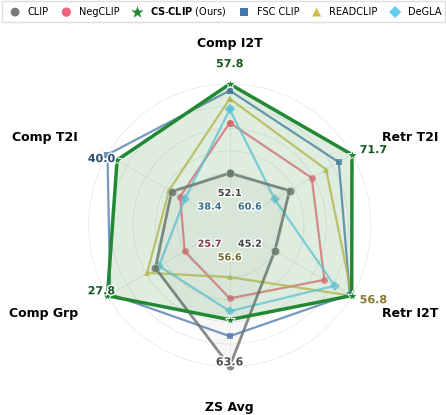


Figure saved to figures/radar_plot_standalone.pdf


In [10]:
# =============================================================================
# STANDALONE RADAR PLOT
# =============================================================================
# Radar plot showing absolute performance across compositional and downstream metrics

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes

# Update plot style
plt.rcParams.update(fontsizes.icml2024())

# =============================================================================
# DATA PREPARATION (reuse from previous cell)
# =============================================================================

RADAR_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
SHOW_MODELS = ["NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
baseline_label = "CLIP"

# Add CLIP to model styles
MODEL_STYLES_FULL = MODEL_STYLES.copy()
MODEL_STYLES_FULL["CLIP"] = {"color": "#777777", "marker": "o", "size": 45, "zorder": 2}

# Get ABSOLUTE values for radar plot
def get_abs_avg(table, models):
    """Get absolute average across all columns for given models."""
    if table.empty:
        return {}
    results = {}
    for model in models:
        if model in table.index:
            results[model] = table.loc[model].mean() * 100  # Percentage
    return results

metrics_abs = {
    "Comp I2T": get_abs_avg(dataset_table, RADAR_MODELS),
    "Comp T2I": get_abs_avg(comp_t2i_table, RADAR_MODELS),
    "Comp Group": get_abs_avg(comp_group_table, RADAR_MODELS),
    "ZS Avg": get_abs_avg(zs_table, RADAR_MODELS),
    "Retr I2T": get_abs_avg(retr_i2t_table, RADAR_MODELS),
    "Retr T2I": get_abs_avg(retr_t2i_table, RADAR_MODELS),
}

# =============================================================================
# CREATE STANDALONE RADAR FIGURE
# =============================================================================

fig, ax_radar = plt.subplots(figsize=(4.5, 4.5), subplot_kw=dict(projection='polar'))

# Metric categories with labels
metric_info = {
    "Comp I2T": {"label": "Comp I2T", "color": "#000000"},
    "Comp T2I": {"label": "Comp T2I", "color": "#000000"},
    "Comp Group": {"label": "Comp Grp", "color": "#000000"},
    "ZS Avg": {"label": "ZS Avg", "color": "#000000"},
    "Retr I2T": {"label": "Retr I2T", "color": "#000000"},
    "Retr T2I": {"label": "Retr T2I", "color": "#000000"},
}

metric_names = list(metric_info.keys())
n_metrics = len(metric_names)

# =============================================================================
# PER-METRIC NORMALIZATION
# =============================================================================

R_INNER = 0.35
R_OUTER = 0.95

metric_ranges = {}
for metric in metric_names:
    values = [metrics_abs[metric].get(model, 0) for model in RADAR_MODELS]
    metric_ranges[metric] = {
        'min': min(values),
        'max': max(values),
        'range': max(values) - min(values),
        'values': {m: metrics_abs[metric].get(m, 0) for m in RADAR_MODELS}
    }

def normalize_value(value, metric):
    """Normalize a value to [R_INNER, R_OUTER] based on metric's range."""
    r = metric_ranges[metric]
    if r['range'] == 0:
        return (R_INNER + R_OUTER) / 2
    normalized = (value - r['min']) / r['range']
    return R_INNER + normalized * (R_OUTER - R_INNER)

# Angles for radar (start from top)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_metrics, endpoint=False).tolist()
angles = [a % (2*np.pi) for a in angles]
angles_closed = angles + angles[:1]

# Store positions for annotations
model_positions = {model: {} for model in RADAR_MODELS}

# Plot each model
for model in RADAR_MODELS:
    values = [normalize_value(metrics_abs[m].get(model, 0), m) for m in metric_names]
    values_closed = values + values[:1]
    
    for i, m in enumerate(metric_names):
        model_positions[model][m] = {
            'angle': angles[i],
            'r_norm': values[i],
            'value': metrics_abs[m].get(model, 0)
        }
    
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    color = style.get("color", "#888888")
    marker = style.get("marker", "o")
    
    if model == "CS-CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.5, 0.15, 1.0, 8, 10
    elif model == "CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.0, 0.06, 0.85, 6, 8
    else:
        lw, alpha_fill, alpha_line, ms, zorder = 1.6, 0.0, 0.75, 5, 5
    
    ax_radar.plot(angles_closed, values_closed, '-', linewidth=lw, color=color, 
                  marker=marker, markersize=ms, alpha=alpha_line, zorder=zorder,
                  markeredgecolor='white' if model in ["CS-CLIP", "CLIP"] else 'none',
                  markeredgewidth=0.6 if model == "CS-CLIP" else 0.3 if model == "CLIP" else 0)
    
    if alpha_fill > 0:
        ax_radar.fill(angles_closed, values_closed, alpha=alpha_fill, color=color, zorder=zorder-1)

ax_radar.set_ylim(0, 1.05)

# =============================================================================
# VALUE ANNOTATIONS
# =============================================================================

def darken_color(hex_color, factor=0.7):
    """Darken a hex color by a factor (0-1, lower = darker)."""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r, g, b = int(r * factor), int(g * factor), int(b * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

for metric_idx, metric in enumerate(metric_names):
    angle = angles[metric_idx]
    angle_deg = np.degrees(angle) % 360
    
    metric_values = [(m, model_positions[m][metric]['r_norm'], model_positions[m][metric]['value']) 
                     for m in RADAR_MODELS]
    metric_values_sorted = sorted(metric_values, key=lambda x: x[2])
    
    min_model, min_r, min_val = metric_values_sorted[0]
    max_model, max_r, max_val = metric_values_sorted[-1]
    
    # Positioning based on angle
    if 60 < angle_deg < 120:  # Top
        ha_out, va_out = 'center', 'bottom'
        ha_in, va_in = 'center', 'top'
        r_offset_out = 0.10
    elif 240 < angle_deg < 300:  # Bottom
        ha_out, va_out = 'center', 'top'
        ha_in, va_in = 'center', 'bottom'
        r_offset_out = -0.06
    elif angle_deg <= 60 or angle_deg >= 300:  # Right
        ha_out, va_out = 'left', 'center'
        ha_in, va_in = 'right', 'center'
        r_offset_out = 0.06
    else:  # Left (120-240)
        ha_out, va_out = 'right', 'center'
        ha_in, va_in = 'left', 'center'
        r_offset_out = -0.06
    
    # Max value (outer)
    max_color = MODEL_STYLES_FULL.get(max_model, {}).get("color", "#888888")
    max_color_dark = darken_color(max_color, 0.65)
    ax_radar.text(angle, max_r + r_offset_out, f'{max_val:.1f}',
                  fontsize=8, fontweight='bold', color=max_color_dark,
                  ha=ha_out, va=va_out, clip_on=False, zorder=15,
                  path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    
    # Min value (inner)
    min_color = MODEL_STYLES_FULL.get(min_model, {}).get("color", "#888888")
    min_color_dark = darken_color(min_color, 0.55)
    inner_text_r = min_r - 0.10
    ax_radar.text(angle, inner_text_r, f'{min_val:.1f}',
                  fontsize=7, fontweight='bold', color=min_color_dark,
                  ha=ha_in, va=va_in, clip_on=False, zorder=15,
                  path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# =============================================================================
# AXIS LABELS
# =============================================================================

ax_radar.set_xticks(angles)
ax_radar.set_xticklabels([])

label_r = 1.18

for i, (angle, metric) in enumerate(zip(angles, metric_names)):
    info = metric_info[metric]
    label = info["label"]
    color = info["color"]
    angle_deg = np.degrees(angle) % 360
    
    if 60 < angle_deg < 120:
        ha, va = 'center', 'bottom'
    elif 240 < angle_deg < 300:
        ha, va = 'center', 'top'
    elif angle_deg <= 60 or angle_deg >= 300:
        ha, va = 'left', 'center'
    else:
        ha, va = 'right', 'center'
    
    ax_radar.text(angle, label_r, label, 
                  ha=ha, va=va,
                  fontsize=9, fontweight='bold', color=color, clip_on=False)

ax_radar.set_yticklabels([])
ax_radar.set_facecolor("white")

# Draw concentric rings
ring_values = [0.35, 0.5, 0.65, 0.8, 0.95]
for r_val in ring_values:
    circle_angles = np.linspace(0, 2*np.pi, 100)
    ax_radar.plot(circle_angles, [r_val]*100, '-', color='#cccccc', linewidth=0.4, alpha=0.6, zorder=1)

# Draw spokes
for angle in angles:
    ax_radar.plot([angle, angle], [0.2, 1.0], '-', color='#cccccc', linewidth=0.4, alpha=0.6, zorder=1)

ax_radar.grid(False)
ax_radar.spines['polar'].set_visible(False)

# =============================================================================
# LEGEND
# =============================================================================

legend_handles = []
legend_labels = []

# CLIP first
style = MODEL_STYLES_FULL["CLIP"]
h = ax_radar.scatter([], [], s=style["size"]*0.9, c=style["color"], marker=style["marker"],
                     edgecolor='none')
legend_handles.append(h)
legend_labels.append("CLIP")

# Other models
for model in SHOW_MODELS:
    style = MODEL_STYLES.get(model, {"color": "#888888", "marker": "o", "size": 40})
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    h = ax_radar.scatter([], [], s=style.get("size", 40)*0.9, c=style.get("color"),
                         marker=style.get("marker", "o"),
                         edgecolor=style.get("edgecolor", "none"),
                         linewidth=style.get("linewidth", 0))
    legend_handles.append(h)
    legend_labels.append(label)

fig.legend(legend_handles, legend_labels, 
           loc='upper center',
           bbox_to_anchor=(0.5, 1.00),
           ncol=6,
           fontsize=7,
           framealpha=0.95,
           edgecolor='#dddddd',
           fancybox=False,
           handletextpad=0.3,
           columnspacing=0.8)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Make room for legend at top
plt.savefig(FIGURES_DIR / "radar_plot_standalone.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "radar_plot_standalone.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'radar_plot_standalone.pdf'}")

/tmp/ipykernel_3720263/1452906388.py:204: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


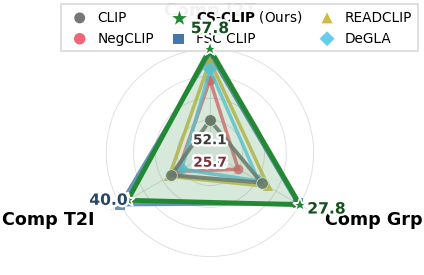


Figure saved to figures/radar_compositional.pdf


In [11]:
# =============================================================================
# RADAR PLOT 1: COMPOSITIONAL METRICS ONLY
# =============================================================================
# Shows: Comp I2T, Comp T2I, Comp Group

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes

plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Models for radar
RADAR_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]

# Compositional metrics only
COMP_METRICS = ["Comp I2T", "Comp T2I", "Comp Group"]

# Reuse metrics_abs from previous cell
comp_metrics_abs = {m: metrics_abs[m] for m in COMP_METRICS}

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(3.2, 3.2), subplot_kw={'projection': 'polar'}, dpi=140)

n_metrics = len(COMP_METRICS)

# Per-metric normalization
R_INNER = 0.30
R_OUTER = 0.95

metric_ranges = {}
for metric in COMP_METRICS:
    values = [comp_metrics_abs[metric].get(model, 0) for model in RADAR_MODELS]
    metric_ranges[metric] = {
        'min': min(values),
        'max': max(values),
        'range': max(values) - min(values),
    }

def normalize_value(value, metric):
    r = metric_ranges[metric]
    if r['range'] == 0:
        return (R_INNER + R_OUTER) / 2
    normalized = (value - r['min']) / r['range']
    return R_INNER + normalized * (R_OUTER - R_INNER)

# Angles (start from top)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_metrics, endpoint=False).tolist()
angles = [a % (2*np.pi) for a in angles]
angles_closed = angles + angles[:1]

# Store positions for annotations
model_positions = {model: {} for model in RADAR_MODELS}

# Plot each model
for model in RADAR_MODELS:
    values = [normalize_value(comp_metrics_abs[m].get(model, 0), m) for m in COMP_METRICS]
    values_closed = values + values[:1]
    
    for i, m in enumerate(COMP_METRICS):
        model_positions[model][m] = {
            'angle': angles[i],
            'r_norm': values[i],
            'value': comp_metrics_abs[m].get(model, 0)
        }
    
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    color = style.get("color", "#888888")
    marker = style.get("marker", "o")
    
    if model == "CS-CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.5, 0.18, 1.0, 8, 10
    elif model == "CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.0, 0.08, 0.85, 6, 8
    else:
        lw, alpha_fill, alpha_line, ms, zorder = 1.8, 0.0, 0.8, 5, 5
    
    ax.plot(angles_closed, values_closed, '-', linewidth=lw, color=color, 
            marker=marker, markersize=ms, alpha=alpha_line, zorder=zorder,
            markeredgecolor='white' if model in ["CS-CLIP", "CLIP"] else 'none',
            markeredgewidth=0.8 if model == "CS-CLIP" else 0.4 if model == "CLIP" else 0)
    
    if alpha_fill > 0:
        ax.fill(angles_closed, values_closed, alpha=alpha_fill, color=color, zorder=zorder-1)

ax.set_ylim(0, 1.1)

# Value annotations
def darken_color(hex_color, factor=0.7):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r, g, b = int(r * factor), int(g * factor), int(b * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

for metric_idx, metric in enumerate(COMP_METRICS):
    angle = angles[metric_idx]
    angle_deg = np.degrees(angle) % 360
    
    metric_values = [(m, model_positions[m][metric]['r_norm'], model_positions[m][metric]['value']) 
                     for m in RADAR_MODELS]
    metric_values_sorted = sorted(metric_values, key=lambda x: x[2])
    
    min_model, min_r, min_val = metric_values_sorted[0]
    max_model, max_r, max_val = metric_values_sorted[-1]
    
    # Positioning based on angle
    if 60 < angle_deg < 120:  # Top
        ha_out, va_out = 'center', 'bottom'
        ha_in, va_in = 'center', 'top'
        r_offset_out = 0.12
    elif 240 < angle_deg < 300:  # Bottom
        ha_out, va_out = 'center', 'top'
        ha_in, va_in = 'center', 'bottom'
        r_offset_out = -0.08
    elif angle_deg <= 60 or angle_deg >= 300:  # Right
        ha_out, va_out = 'left', 'center'
        ha_in, va_in = 'right', 'center'
        r_offset_out = 0.08
    else:  # Left
        ha_out, va_out = 'right', 'center'
        ha_in, va_in = 'left', 'center'
        r_offset_out = -0.08
    
    # Max value
    max_color = MODEL_STYLES_FULL.get(max_model, {}).get("color", "#888888")
    max_color_dark = darken_color(max_color, 0.6)
    ax.text(angle, max_r + r_offset_out, f'{max_val:.1f}',
            fontsize=8, fontweight='bold', color=max_color_dark,
            ha=ha_out, va=va_out, clip_on=False, zorder=15,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    
    # Min value
    min_color = MODEL_STYLES_FULL.get(min_model, {}).get("color", "#888888")
    min_color_dark = darken_color(min_color, 0.5)
    ax.text(angle, min_r - 0.12, f'{min_val:.1f}',
            fontsize=7, fontweight='bold', color=min_color_dark,
            ha=ha_in, va=va_in, clip_on=False, zorder=15,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# Axis labels
ax.set_xticks(angles)
ax.set_xticklabels([])

label_r = 1.22
metric_labels = {"Comp I2T": "Comp I2T", "Comp T2I": "Comp T2I", "Comp Group": "Comp Grp"}

for angle, metric in zip(angles, COMP_METRICS):
    angle_deg = np.degrees(angle) % 360
    if 60 < angle_deg < 120:
        ha, va = 'center', 'bottom'
    elif 240 < angle_deg < 300:
        ha, va = 'center', 'top'
    elif angle_deg <= 60 or angle_deg >= 300:
        ha, va = 'left', 'center'
    else:
        ha, va = 'right', 'center'
    
    ax.text(angle, label_r, metric_labels[metric], 
            ha=ha, va=va, fontsize=9, fontweight='bold', color='black', clip_on=False)

ax.set_yticklabels([])
ax.set_facecolor("white")

# Draw rings
ring_values = [0.30, 0.50, 0.70, 0.95]
for r_val in ring_values:
    circle_angles = np.linspace(0, 2*np.pi, 100)
    ax.plot(circle_angles, [r_val]*100, '-', color='#cccccc', linewidth=0.5, alpha=0.6, zorder=1)

# Draw spokes
for angle in angles:
    ax.plot([angle, angle], [0.15, 1.05], '-', color='#cccccc', linewidth=0.5, alpha=0.6, zorder=1)

ax.grid(False)
ax.spines['polar'].set_visible(False)

# Legend
legend_handles = []
legend_labels = []

for model in RADAR_MODELS:
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    h = ax.scatter([], [], s=style.get("size", 40)*0.7, c=style.get("color"),
                   marker=style.get("marker", "o"),
                   edgecolor=style.get("edgecolor", "none"),
                   linewidth=style.get("linewidth", 0))
    legend_handles.append(h)
    legend_labels.append(label)

ax.legend(legend_handles, legend_labels, 
          loc='upper left', bbox_to_anchor=(-0.15, 1.15),
          ncol=3, fontsize=7, framealpha=0.95, edgecolor='#dddddd',
          fancybox=False, columnspacing=0.8, handletextpad=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_compositional.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "radar_compositional.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'radar_compositional.pdf'}")

/tmp/ipykernel_3720263/563635642.py:204: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


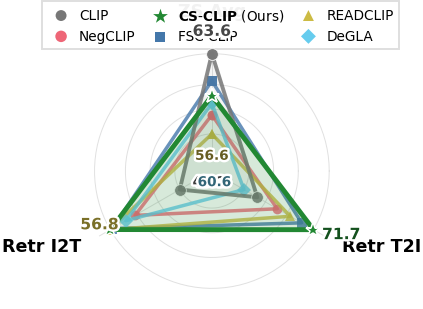


Figure saved to figures/radar_downstream.pdf


In [12]:
# =============================================================================
# RADAR PLOT 2: DOWNSTREAM METRICS ONLY
# =============================================================================
# Shows: ZS Avg, Retr I2T, Retr T2I

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes

plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Models for radar
RADAR_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]

# Downstream metrics only
DOWNSTREAM_METRICS = ["ZS Avg", "Retr I2T", "Retr T2I"]

# Reuse metrics_abs from previous cell
downstream_metrics_abs = {m: metrics_abs[m] for m in DOWNSTREAM_METRICS}

# =============================================================================
# CREATE FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(3.2, 3.2), subplot_kw={'projection': 'polar'}, dpi=140)

n_metrics = len(DOWNSTREAM_METRICS)

# Per-metric normalization
R_INNER = 0.30
R_OUTER = 0.95

metric_ranges = {}
for metric in DOWNSTREAM_METRICS:
    values = [downstream_metrics_abs[metric].get(model, 0) for model in RADAR_MODELS]
    metric_ranges[metric] = {
        'min': min(values),
        'max': max(values),
        'range': max(values) - min(values),
    }

def normalize_value(value, metric):
    r = metric_ranges[metric]
    if r['range'] == 0:
        return (R_INNER + R_OUTER) / 2
    normalized = (value - r['min']) / r['range']
    return R_INNER + normalized * (R_OUTER - R_INNER)

# Angles (start from top)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_metrics, endpoint=False).tolist()
angles = [a % (2*np.pi) for a in angles]
angles_closed = angles + angles[:1]

# Store positions for annotations
model_positions = {model: {} for model in RADAR_MODELS}

# Plot each model
for model in RADAR_MODELS:
    values = [normalize_value(downstream_metrics_abs[m].get(model, 0), m) for m in DOWNSTREAM_METRICS]
    values_closed = values + values[:1]
    
    for i, m in enumerate(DOWNSTREAM_METRICS):
        model_positions[model][m] = {
            'angle': angles[i],
            'r_norm': values[i],
            'value': downstream_metrics_abs[m].get(model, 0)
        }
    
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    color = style.get("color", "#888888")
    marker = style.get("marker", "o")
    
    if model == "CS-CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.5, 0.18, 1.0, 8, 10
    elif model == "CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.0, 0.08, 0.85, 6, 8
    else:
        lw, alpha_fill, alpha_line, ms, zorder = 1.8, 0.0, 0.8, 5, 5
    
    ax.plot(angles_closed, values_closed, '-', linewidth=lw, color=color, 
            marker=marker, markersize=ms, alpha=alpha_line, zorder=zorder,
            markeredgecolor='white' if model in ["CS-CLIP", "CLIP"] else 'none',
            markeredgewidth=0.8 if model == "CS-CLIP" else 0.4 if model == "CLIP" else 0)
    
    if alpha_fill > 0:
        ax.fill(angles_closed, values_closed, alpha=alpha_fill, color=color, zorder=zorder-1)

ax.set_ylim(0, 1.1)

# Value annotations
def darken_color(hex_color, factor=0.7):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r, g, b = int(r * factor), int(g * factor), int(b * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

for metric_idx, metric in enumerate(DOWNSTREAM_METRICS):
    angle = angles[metric_idx]
    angle_deg = np.degrees(angle) % 360
    
    metric_values = [(m, model_positions[m][metric]['r_norm'], model_positions[m][metric]['value']) 
                     for m in RADAR_MODELS]
    metric_values_sorted = sorted(metric_values, key=lambda x: x[2])
    
    min_model, min_r, min_val = metric_values_sorted[0]
    max_model, max_r, max_val = metric_values_sorted[-1]
    
    # Positioning based on angle
    if 60 < angle_deg < 120:  # Top
        ha_out, va_out = 'center', 'bottom'
        ha_in, va_in = 'center', 'top'
        r_offset_out = 0.12
    elif 240 < angle_deg < 300:  # Bottom
        ha_out, va_out = 'center', 'top'
        ha_in, va_in = 'center', 'bottom'
        r_offset_out = -0.08
    elif angle_deg <= 60 or angle_deg >= 300:  # Right
        ha_out, va_out = 'left', 'center'
        ha_in, va_in = 'right', 'center'
        r_offset_out = 0.08
    else:  # Left
        ha_out, va_out = 'right', 'center'
        ha_in, va_in = 'left', 'center'
        r_offset_out = -0.08
    
    # Max value
    max_color = MODEL_STYLES_FULL.get(max_model, {}).get("color", "#888888")
    max_color_dark = darken_color(max_color, 0.6)
    ax.text(angle, max_r + r_offset_out, f'{max_val:.1f}',
            fontsize=8, fontweight='bold', color=max_color_dark,
            ha=ha_out, va=va_out, clip_on=False, zorder=15,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    
    # Min value
    min_color = MODEL_STYLES_FULL.get(min_model, {}).get("color", "#888888")
    min_color_dark = darken_color(min_color, 0.5)
    ax.text(angle, min_r - 0.12, f'{min_val:.1f}',
            fontsize=7, fontweight='bold', color=min_color_dark,
            ha=ha_in, va=va_in, clip_on=False, zorder=15,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# Axis labels
ax.set_xticks(angles)
ax.set_xticklabels([])

label_r = 1.22
metric_labels = {"ZS Avg": "ZS Avg", "Retr I2T": "Retr I2T", "Retr T2I": "Retr T2I"}

for angle, metric in zip(angles, DOWNSTREAM_METRICS):
    angle_deg = np.degrees(angle) % 360
    if 60 < angle_deg < 120:
        ha, va = 'center', 'bottom'
    elif 240 < angle_deg < 300:
        ha, va = 'center', 'top'
    elif angle_deg <= 60 or angle_deg >= 300:
        ha, va = 'left', 'center'
    else:
        ha, va = 'right', 'center'
    
    ax.text(angle, label_r, metric_labels[metric], 
            ha=ha, va=va, fontsize=9, fontweight='bold', color='black', clip_on=False)

ax.set_yticklabels([])
ax.set_facecolor("white")

# Draw rings
ring_values = [0.30, 0.50, 0.70, 0.95]
for r_val in ring_values:
    circle_angles = np.linspace(0, 2*np.pi, 100)
    ax.plot(circle_angles, [r_val]*100, '-', color='#cccccc', linewidth=0.5, alpha=0.6, zorder=1)

# Draw spokes
for angle in angles:
    ax.plot([angle, angle], [0.15, 1.05], '-', color='#cccccc', linewidth=0.5, alpha=0.6, zorder=1)

ax.grid(False)
ax.spines['polar'].set_visible(False)

# Legend
legend_handles = []
legend_labels = []

for model in RADAR_MODELS:
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    h = ax.scatter([], [], s=style.get("size", 40)*0.7, c=style.get("color"),
                   marker=style.get("marker", "o"),
                   edgecolor=style.get("edgecolor", "none"),
                   linewidth=style.get("linewidth", 0))
    legend_handles.append(h)
    legend_labels.append(label)

ax.legend(legend_handles, legend_labels, 
          loc='upper left', bbox_to_anchor=(-0.15, 1.15),
          ncol=3, fontsize=7, framealpha=0.95, edgecolor='#dddddd',
          fancybox=False, columnspacing=0.8, handletextpad=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_downstream.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "radar_downstream.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'radar_downstream.pdf'}")

/tmp/ipykernel_3720263/4278400396.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


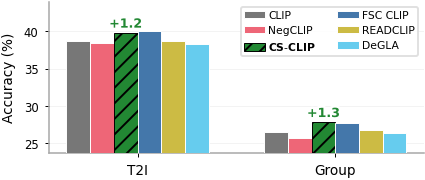


Figure saved to figures/comp_t2i_group_bars.pdf


In [13]:
# =============================================================================
# COMPACT PLOT: Compositional T2I & Group Accuracy (Modern Grouped Bar Chart)
# =============================================================================
# A clean, modern bar chart showing model performance on T2I and Group metrics

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes

# Use ICML single column width
icml_size = figsizes.icml2024_half()
plt.rcParams.update(icml_size)
plt.rcParams.update(fontsizes.icml2024())

# Models and metrics - include CLIP for comparison
SHOW_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]
FOCUS_METRICS = ["Comp T2I", "Comp Group"]

# Get absolute values (not deltas)
def get_abs_avg(table, models):
    if table.empty:
        return {}
    results = {}
    for model in models:
        if model in table.index:
            results[model] = table.loc[model].mean() * 100  # Percentage
    return results

abs_values = {
    "Comp T2I": get_abs_avg(comp_t2i_table, SHOW_MODELS),
    "Comp Group": get_abs_avg(comp_group_table, SHOW_MODELS),
}

# =============================================================================
# CREATE MODERN GROUPED BAR CHART
# =============================================================================
fig_width = icml_size['figure.figsize'][0]
fig, ax = plt.subplots(figsize=(fig_width, 1.5), dpi=140)

metric_labels = {"Comp T2I": "T2I", "Comp Group": "Group"}
n_metrics = len(FOCUS_METRICS)
n_models = len(SHOW_MODELS)

# X positions for metrics
x = np.arange(n_metrics)
bar_width = 0.12
offsets = np.linspace(-(n_models-1)/2 * bar_width, (n_models-1)/2 * bar_width, n_models)

# Store CS-CLIP bar positions for delta annotation
cs_clip_positions = {}

# Plot bars for each model - consistent styling with other plots
for i, model in enumerate(SHOW_MODELS):
    values = [abs_values[m].get(model, 0) for m in FOCUS_METRICS]
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888"})
    color = style.get("color", "#888888")
    
    # Display name for legend
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$"
        edgecolor = 'black'
        lw = 0.5
        hatch = '///'
    else:
        label = display_name
        edgecolor = 'white'
        lw = 0.5
        hatch = None
    
    bars = ax.bar(x + offsets[i], values, bar_width, label=label, color=color, 
                  edgecolor=edgecolor, linewidth=lw, zorder=3, hatch=hatch)
    
    # Store CS-CLIP positions
    if model == "CS-CLIP":
        for j, (bar, metric) in enumerate(zip(bars, FOCUS_METRICS)):
            cs_clip_positions[metric] = {
                'x': bar.get_x() + bar.get_width()/2,
                'y': bar.get_height(),
                'value': values[j]
            }

# Add delta annotations on top of CS-CLIP bars
clip_values = {m: abs_values[m].get("CLIP", 0) for m in FOCUS_METRICS}
for metric in FOCUS_METRICS:
    pos = cs_clip_positions[metric]
    delta = pos['value'] - clip_values[metric]
    ax.annotate(f'+{delta:.1f}', 
                xy=(pos['x'], pos['y'] + 0.3),
                ha='center', va='bottom', fontsize=6.5, fontweight='bold',
                color='#228833',  # Consistent green from palette
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in FOCUS_METRICS], fontsize=7)
ax.set_ylabel("Accuracy (%)", fontsize=7)
ax.tick_params(axis='y', labelsize=6)

# Clean white background - consistent with other plots
ax.set_facecolor("white")
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.4, color='#cccccc', zorder=0)

# Consistent spine styling with other plots
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#aaaaaa")
ax.spines["bottom"].set_color("#aaaaaa")
ax.tick_params(axis='both', length=2, width=0.5)

# Y-axis limits
all_vals = [v for d in abs_values.values() for v in d.values()]
y_min = min(all_vals) - 2
y_max = max(all_vals) + 4
ax.set_ylim(y_min, y_max)

# Legend - top right inside the plot to save space
ax.legend(loc='upper right', fontsize=5.5, frameon=True, framealpha=0.9,
          edgecolor='#dddddd', handletextpad=0.3, borderpad=0.3, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comp_t2i_group_bars.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "comp_t2i_group_bars.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'comp_t2i_group_bars.pdf'}")

Zero-shot datasets: ['wds_imagenet-o', 'wds_imagenet1k', 'wds_imagenet_sketch', 'wds_imagenetv2', 'wds_sun397', 'wds_vtab-caltech101', 'wds_vtab-cifar10']
Retrieval datasets: ['wds_flickr8k', 'wds_mscoco_captions']

Total metrics for radar: 11
Metrics: ['ZS: wds_imagenet-o', 'ZS: wds_imagenet1k', 'ZS: wds_imagenet_sketch', 'ZS: wds_imagenetv2', 'ZS: wds_sun397', 'ZS: wds_vtab-caltech101', 'ZS: wds_vtab-cifar10', 'I2T: wds_flickr8k', 'I2T: wds_mscoco_captions', 'T2I: wds_flickr8k', 'T2I: wds_mscoco_captions']


/tmp/ipykernel_3720263/3028511906.py:191: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


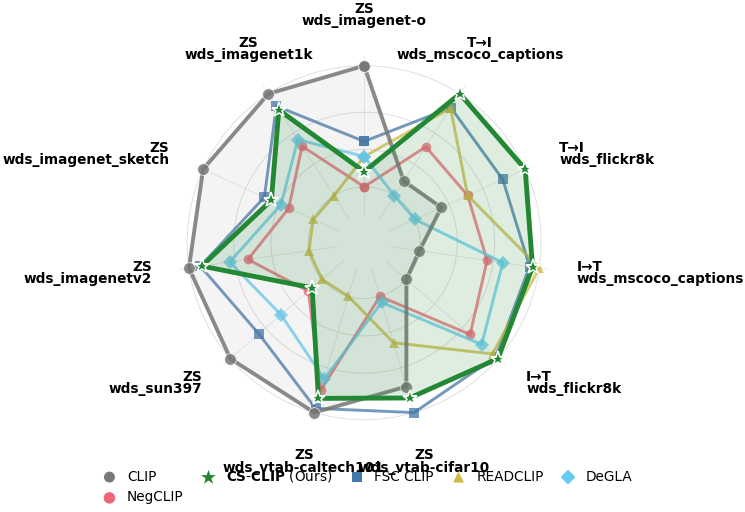


Figure saved to figures/radar_downstream_datasets.pdf


In [14]:
# =============================================================================
# RADAR PLOT: Zero-Shot & Retrieval Individual Datasets
# =============================================================================
# Shows individual dataset performance for downstream tasks

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from tueplots import figsizes, fontsizes

# Use ICML FULL width for larger, less cluttered plot
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Models to show
RADAR_MODELS = ["CLIP", "NegCLIP (COCO)", "CS-CLIP", "FSC CLIP (COCO)", "READCLIP", "DeGLA"]

# Get individual dataset values from tables
# Zero-shot datasets
zs_datasets = list(zs_table.columns) if not zs_table.empty else []
# Retrieval datasets (I2T and T2I share same datasets typically)
retr_datasets = list(retr_i2t_table.columns) if not retr_i2t_table.empty else []

print(f"Zero-shot datasets: {zs_datasets}")
print(f"Retrieval datasets: {retr_datasets}")

# Build metrics dict with individual datasets
# Format: "ZS: DatasetName" or "Retr: DatasetName (I2T/T2I)"
downstream_datasets = {}

# Add zero-shot datasets
for ds in zs_datasets:
    key = f"ZS: {ds}"
    downstream_datasets[key] = {}
    for model in RADAR_MODELS:
        if model in zs_table.index:
            downstream_datasets[key][model] = zs_table.loc[model, ds] * 100

# Add retrieval I2T datasets
for ds in retr_datasets:
    key = f"I2T: {ds}"
    downstream_datasets[key] = {}
    for model in RADAR_MODELS:
        if model in retr_i2t_table.index:
            downstream_datasets[key][model] = retr_i2t_table.loc[model, ds] * 100

# Add retrieval T2I datasets  
for ds in retr_datasets:
    key = f"T2I: {ds}"
    downstream_datasets[key] = {}
    for model in RADAR_MODELS:
        if model in retr_t2i_table.index:
            downstream_datasets[key][model] = retr_t2i_table.loc[model, ds] * 100

metric_names = list(downstream_datasets.keys())
n_metrics = len(metric_names)

print(f"\nTotal metrics for radar: {n_metrics}")
print(f"Metrics: {metric_names}")

# =============================================================================
# CREATE LARGER RADAR PLOT
# =============================================================================
# Use full width for better readability
fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw={'projection': 'polar'}, dpi=140)

# Per-metric normalization
R_INNER = 0.30
R_OUTER = 0.95

metric_ranges = {}
for metric in metric_names:
    values = [downstream_datasets[metric].get(model, 0) for model in RADAR_MODELS]
    metric_ranges[metric] = {
        'min': min(values),
        'max': max(values),
        'range': max(values) - min(values),
    }

def normalize_value(value, metric):
    r = metric_ranges[metric]
    if r['range'] == 0:
        return (R_INNER + R_OUTER) / 2
    normalized = (value - r['min']) / r['range']
    return R_INNER + normalized * (R_OUTER - R_INNER)

# Angles (start from top)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_metrics, endpoint=False).tolist()
angles = [a % (2*np.pi) for a in angles]
angles_closed = angles + angles[:1]

# Plot each model with larger markers
for model in RADAR_MODELS:
    values = [normalize_value(downstream_datasets[m].get(model, 0), m) for m in metric_names]
    values_closed = values + values[:1]
    
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    color = style.get("color", "#888888")
    marker = style.get("marker", "o")
    
    if model == "CS-CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.5, 0.15, 1.0, 8, 10
    elif model == "CLIP":
        lw, alpha_fill, alpha_line, ms, zorder = 2.0, 0.08, 0.85, 6, 8
    else:
        lw, alpha_fill, alpha_line, ms, zorder = 1.5, 0.0, 0.75, 5, 5
    
    ax.plot(angles_closed, values_closed, '-', linewidth=lw, color=color, 
            marker=marker, markersize=ms, alpha=alpha_line, zorder=zorder,
            markeredgecolor='white' if model in ["CS-CLIP", "CLIP"] else 'none',
            markeredgewidth=0.8 if model == "CS-CLIP" else 0.4 if model == "CLIP" else 0)
    
    if alpha_fill > 0:
        ax.fill(angles_closed, values_closed, alpha=alpha_fill, color=color, zorder=zorder-1)

ax.set_ylim(0, 1.1)

# Axis labels - larger font for readability
ax.set_xticks(angles)
ax.set_xticklabels([])

# Add labels manually with appropriate positioning - larger font
label_r = 1.15
for i, (angle, metric) in enumerate(zip(angles, metric_names)):
    angle_deg = np.degrees(angle) % 360
    
    # Shorten label
    short_label = metric.replace("ZS: ", "").replace("I2T: ", "").replace("T2I: ", "")
    # Add prefix indicator
    if metric.startswith("ZS:"):
        prefix = "ZS"
    elif metric.startswith("I2T:"):
        prefix = "I→T"
    else:
        prefix = "T→I"
    
    # Position text
    if 45 < angle_deg < 135:
        ha, va = 'center', 'bottom'
    elif 225 < angle_deg < 315:
        ha, va = 'center', 'top'
    elif angle_deg <= 45 or angle_deg >= 315:
        ha, va = 'left', 'center'
    else:
        ha, va = 'right', 'center'
    
    # Larger font for better readability
    ax.text(angle, label_r, f"{prefix}\n{short_label}", 
            ha=ha, va=va, fontsize=7, fontweight='bold', color='black', 
            clip_on=False, linespacing=0.85)

ax.set_yticklabels([])
ax.set_facecolor("white")

# Draw rings
ring_values = [0.30, 0.50, 0.70, 0.95]
for r_val in ring_values:
    circle_angles = np.linspace(0, 2*np.pi, 100)
    ax.plot(circle_angles, [r_val]*100, '-', color='#cccccc', linewidth=0.5, alpha=0.6, zorder=1)

# Draw spokes
for angle in angles:
    ax.plot([angle, angle], [0.15, 1.0], '-', color='#cccccc', linewidth=0.4, alpha=0.5, zorder=1)

ax.grid(False)
ax.spines['polar'].set_visible(False)

# Legend - larger and clearer
legend_handles = []
legend_labels = []

for model in RADAR_MODELS:
    style = MODEL_STYLES_FULL.get(model, {"color": "#888888", "marker": "o", "size": 40})
    display_name = model.replace(" (COCO)", "").replace(" (CC3M)", "")
    if model == "CS-CLIP":
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    else:
        label = display_name
    
    h = ax.scatter([], [], s=style.get("size", 40)*0.7, c=style.get("color"),
                   marker=style.get("marker", "o"),
                   edgecolor=style.get("edgecolor", "none"),
                   linewidth=style.get("linewidth", 0))
    legend_handles.append(h)
    legend_labels.append(label)

ax.legend(legend_handles, legend_labels, 
          loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=5, fontsize=7, frameon=False, columnspacing=0.8, handletextpad=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_downstream_datasets.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "radar_downstream_datasets.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'radar_downstream_datasets.pdf'}")

Available models in cap_table_sub: ['CE CLIP', 'CLIC CogVLM (LAION)', 'CLIC CogVLM (PixPR RedCaps)', 'CLIP', 'CLoVe', 'CON CLIP', 'CS-CLIP', 'DAC (LLM)', 'DAC (SAM)', 'DeGLA', 'FSC CLIP (CC3M)', 'FSC CLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'LaCLIP (CC12M)', 'LabCLIP', 'NegCLIP (COCO)', 'READCLIP', 'TSVLC', 'TripletCLIP (CC12M)']
Found data for models: ['CLIP', 'NegCLIP', 'CS-CLIP']


/tmp/ipykernel_3720263/2484578580.py:183: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


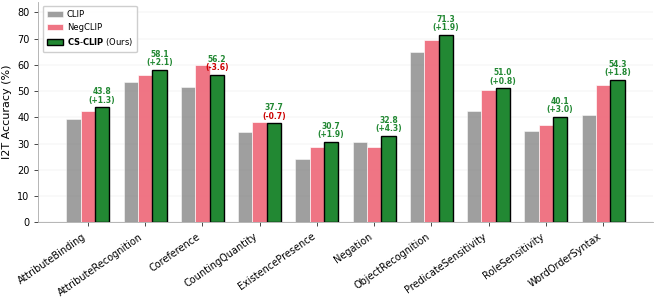


Figure saved to figures/sublevel_capability_comparison.pdf


In [16]:
# =============================================================================
# SUB-LEVEL CAPABILITY ANALYSIS: CLIP vs NegCLIP vs CS-CLIP
# =============================================================================
# Modern grouped bar plot comparing performance across fine-grained capabilities

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from tueplots import figsizes, fontsizes

# Update plot style
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# =============================================================================
# DATA PREPARATION
# =============================================================================

# Models to compare
COMPARE_MODELS = ["CLIP", "NegCLIP", "CS-CLIP"]

# Consistent color scheme (using established colors)
COMPARE_COLORS = {
    "CLIP": "#777777",  # Gray baseline
    "NegCLIP": COLORBLIND_PALETTE[1],  # Orange (same as NegCLIP (COCO))
    "CS-CLIP": COLORBLIND_PALETTE[2],  # Green (ours)
}

# Map full model names to short names if needed
MODEL_NAME_MAP = {
    "NegCLIP (COCO)": "NegCLIP",
    "NegCLIP": "NegCLIP",
    "CLIP": "CLIP",
    "CS-CLIP": "CS-CLIP",
}

# Get sub-level capability data
# Check what models are available
available_models = cap_table_sub.index.tolist()
print(f"Available models in cap_table_sub: {available_models}")

# Find matching model names
model_data = {}
for target_model in COMPARE_MODELS:
    # Try exact match first
    if target_model in available_models:
        model_data[target_model] = cap_table_sub.loc[target_model]
    else:
        # Try with suffix
        for avail in available_models:
            short_name = MODEL_NAME_MAP.get(avail, avail)
            if short_name == target_model or target_model in avail:
                model_data[target_model] = cap_table_sub.loc[avail]
                break

print(f"Found data for models: {list(model_data.keys())}")

# Get capabilities (columns)
capabilities = list(cap_table_sub.columns)
n_caps = len(capabilities)

# Convert to percentages
data_pct = {model: values * 100 for model, values in model_data.items()}

# =============================================================================
# CREATE MODERN GROUPED BAR CHART
# =============================================================================

fig, ax = plt.subplots(figsize=(6.75, 3.2))

# Bar configuration
n_models = len(COMPARE_MODELS)
bar_width = 0.25
x = np.arange(n_caps)

# Calculate offsets for grouped bars
offsets = np.linspace(-(n_models-1)/2 * bar_width, (n_models-1)/2 * bar_width, n_models)

# Plot bars for each model
for i, model in enumerate(COMPARE_MODELS):
    if model not in data_pct:
        continue
    
    values = [data_pct[model].get(cap, 0) for cap in capabilities]
    color = COMPARE_COLORS.get(model, "#888888")
    
    # Style variations
    if model == "CS-CLIP":
        edgecolor = 'black'
        linewidth = 1.0
        hatch = ''
        alpha = 1.0
        label = r"$\mathbf{CS\text{-}CLIP}$ (Ours)"
    elif model == "CLIP":
        edgecolor = 'white'
        linewidth = 0.5
        hatch = ''
        alpha = 0.7
        label = "CLIP"
    else:
        edgecolor = 'white'
        linewidth = 0.5
        hatch = ''
        alpha = 0.9
        label = model
    
    bars = ax.bar(x + offsets[i], values, bar_width, 
                  label=label, color=color, 
                  edgecolor=edgecolor, linewidth=linewidth,
                  alpha=alpha, zorder=3, hatch=hatch)
    
    # Store CS-CLIP bars and values for delta annotation
    if model == "CS-CLIP":
        cs_clip_bars = bars
        cs_clip_values = values

# Add delta annotations (CS-CLIP - NegCLIP) above CS-CLIP bars
if "CS-CLIP" in data_pct and "NegCLIP" in data_pct:
    for i, cap in enumerate(capabilities):
        cs_val = data_pct["CS-CLIP"].get(cap, 0)
        neg_val = data_pct["NegCLIP"].get(cap, 0)
        delta = cs_val - neg_val
        
        bar = cs_clip_bars[i]
        height = bar.get_height()
        
        # Show absolute value and delta (red if negative)
        delta_sign = "+" if delta >= 0 else ""
        delta_color = COMPARE_COLORS["CS-CLIP"] if delta >= 0 else "#cc0000"
        
        # Two separate annotations for different colors
        ax.annotate(f'{cs_val:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 8),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=5.5, fontweight='bold',
                   color=COMPARE_COLORS["CS-CLIP"])
        ax.annotate(f'({delta_sign}{delta:.1f})',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 2),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=5.5, fontweight='bold',
                   color=delta_color)

# =============================================================================
# STYLING
# =============================================================================

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(capabilities, fontsize=8, rotation=35, ha='right')

# Y-axis
ax.set_ylabel("I2T Accuracy (%)", fontsize=8)
ax.set_ylim(0, max([data_pct[m].max() for m in data_pct]) * 1.18)  # Extra space for delta annotations

# Grid - subtle horizontal lines only
ax.yaxis.grid(True, linestyle='-', linewidth=0.3, alpha=0.5, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#aaaaaa')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_color('#aaaaaa')
ax.spines['bottom'].set_linewidth(0.6)

# Background
ax.set_facecolor('white')

# Tick parameters
ax.tick_params(axis='both', length=3, width=0.5, labelsize=7)

# Legend - top right
# Legend - upper left to avoid conflict with bars
ax.legend(loc='upper left', fontsize=6, framealpha=0.95, 
          handletextpad=0.4, borderpad=0.5)

# Title
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sublevel_capability_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig(FIGURES_DIR / "sublevel_capability_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nFigure saved to {FIGURES_DIR / 'sublevel_capability_comparison.pdf'}")